**0. Nạp dữ liệu**

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys; sys.path.insert(0, ".")
import importlib, _common; importlib.reload(_common)
from _common import *
import numpy as np, pandas as pd, matplotlib.pyplot as plt

setup()
df, dfU, dfL = load()

BINS = np.linspace(0, df.distance.max(), 16)
DAYS = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]

# Bang cap THI TRUONG cho surge (bo Shared, khu trung lap ~2.1 lan)
_L = dfL[dfL.name != "Shared"]
TT = _L.groupby(["timestamp", "source", "destination"], as_index=False).agg(
        surge=("surge_multiplier", "mean"),
        hour_local=("hour_local", "first"),
        weekday_local=("weekday_local", "first"),
        is_weekend=("is_weekend", "first"),
        date_local=("date_local", "first"))
TT["co_surge"] = (TT.surge > 1).astype(int)
print(f"Bang cap thi truong (cho surge): {len(TT):,} quan sat doc lap")
print(f"  Ty le co surge: {TT.co_surge.mean()*100:.2f}%")

Nguon: C:\Users\Admin\OneDrive\Máy tính\Pricing_Reseach_Vin AI\data\dataset_clean.parquet
  df  (ca 2 hang, chi de SO SANH): 637,322 chuyen x 63 cot
  dfU (Uber) : 330,070 chuyen | gia TB 15.80 USD | surge: KHONG CO (toan bo = 1.0)
  dfL (Lyft) : 307,252 chuyen | gia TB 17.35 USD | surge 6.83% (20,975 cuoc)
Bang cap thi truong (cho surge): 120,067 quan sat doc lap
  Ty le co surge: 8.64%


**1. ⚠️ Số bản ghi KHÔNG phải nhu cầu**

Trước khi phân tích giờ, phải làm rõ một điều: **không thể dùng số chuyến làm chỉ báo nhu cầu.**

So ban ghi theo gio: thap nhat 22,328 (gio 3) | cao nhat 29,836 (gio 19)
  Ty le cao/thap = 1.34 lan   |   CV = 0.074

BA BANG CHUNG cho thay day la LICH CRAWL:
  [1] Bien thien qua phang: 1.34 lan
      Nhu cau goi xe that: 3-4h sang thap hon 18h khoang 8-15 lan
  [2] 12 khu co hinh dang giong nhau: r trung binh = 0.801
      Nhu cau that phai khac nhau (khu van phong vs khu truong hoc)
  [3] Khong lien quan surge: r(so ban ghi, ty le surge) = 0.026

=> KHONG dung so ban ghi lam feature hay lam proxy cho cau.
   Nhung GIA va SURGE van la gia tri THAT -> van phan tich duoc.
   Lich crawl DEU con co loi: moi gio duoc lay mau nhu nhau
   -> ty le surge do duoc la uoc luong KHONG THIEN LECH.


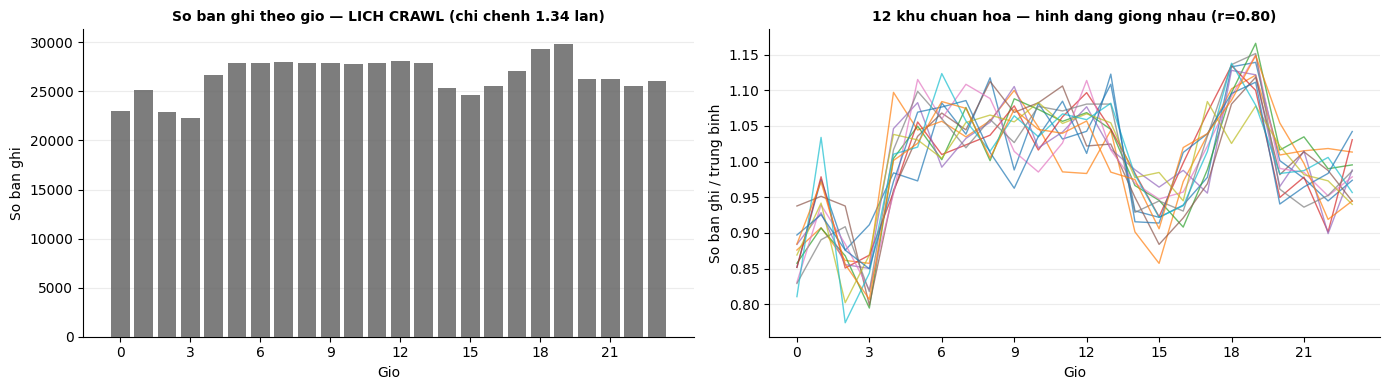

In [2]:
h = df.groupby("hour_local").size()
print(f"So ban ghi theo gio: thap nhat {h.min():,} (gio {h.idxmin()}) | "
      f"cao nhat {h.max():,} (gio {h.idxmax()})")
print(f"  Ty le cao/thap = {h.max()/h.min():.2f} lan   |   CV = {h.std()/h.mean():.3f}")
print()
print("BA BANG CHUNG cho thay day la LICH CRAWL:")
print(f"  [1] Bien thien qua phang: {h.max()/h.min():.2f} lan")
print(f"      Nhu cau goi xe that: 3-4h sang thap hon 18h khoang 8-15 lan")
pv = df.pivot_table(index="hour_local", columns="source", aggfunc="size")
cor = pv.corr().values[np.triu_indices(df.source.nunique(), 1)]
print(f"  [2] 12 khu co hinh dang giong nhau: r trung binh = {cor.mean():.3f}")
print(f"      Nhu cau that phai khac nhau (khu van phong vs khu truong hoc)")
g = dfL.groupby("hour_local").agg(n=("price", "size"), s=("is_surge", "mean"))
print(f"  [3] Khong lien quan surge: r(so ban ghi, ty le surge) = {np.corrcoef(g.n, g.s)[0,1]:.3f}")
print()
print("=> KHONG dung so ban ghi lam feature hay lam proxy cho cau.")
print("   Nhung GIA va SURGE van la gia tri THAT -> van phan tich duoc.")
print("   Lich crawl DEU con co loi: moi gio duoc lay mau nhu nhau")
print("   -> ty le surge do duoc la uoc luong KHONG THIEN LECH.")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(h.index, h.values, color=MUT, alpha=.85, zorder=3)
ax[0].set_title(f"So ban ghi theo gio — LICH CRAWL (chi chenh {h.max()/h.min():.2f} lan)",
                fontweight="bold", fontsize=10)
ax[0].set_xlabel("Gio"); ax[0].set_ylabel("So ban ghi")
for khu in sorted(df.source.unique()):
    v = df[df.source == khu].groupby("hour_local").size()
    ax[1].plot(v.index, v.values / v.mean(), lw=1, alpha=.7)
ax[1].set_title(f"12 khu chuan hoa — hinh dang giong nhau (r={cor.mean():.2f})",
                fontweight="bold", fontsize=10)
ax[1].set_xlabel("Gio"); ax[1].set_ylabel("So ban ghi / trung binh")
for a in ax: a.set_xticks(range(0, 24, 3)); a.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

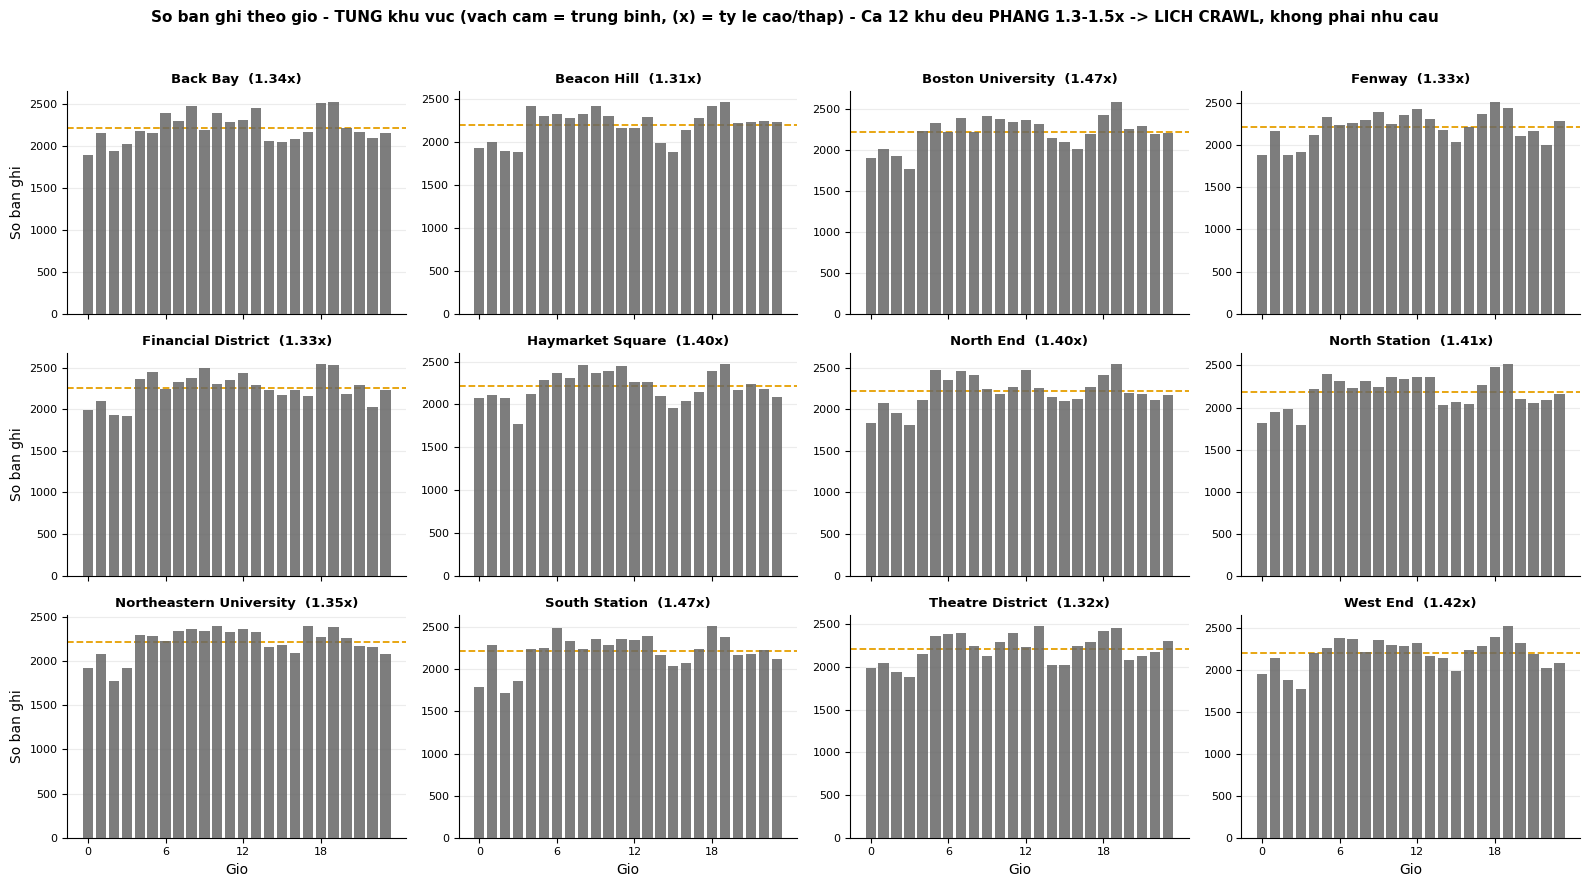

Ty le cao/thap cua 12 khu: 1.31x - 1.47x  (deu duoi 1.5x)
=> Neu la nhu cau that, cac khu chuc nang khac nhau (van phong, truong hoc,
   nha ga) phai co dinh gio KHAC nhau. O day tat ca deu phang giong het.


In [3]:
# Bang chung [1b]: TUNG khu vuc deu phang -> lich crawl, khong phai nhu cau
KHU = sorted(df.source.unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
for ax, khu in zip(axes.flat, KHU):
    hk = df[df.source == khu].groupby("hour_local").size().reindex(range(24), fill_value=0)
    ax.bar(hk.index, hk.values, color=MUT, alpha=.85, zorder=3)
    ax.axhline(hk.mean(), color=ORANGE, ls="--", lw=1.3)
    ax.set_title(f"{khu}  ({hk.max()/hk.min():.2f}x)", fontsize=9.5, fontweight="bold")
    ax.set_xticks(range(0, 24, 6)); ax.tick_params(labelsize=8); ax.grid(axis="x", visible=False)
for a in axes[-1]: a.set_xlabel("Gio")
for a in axes[:, 0]: a.set_ylabel("So ban ghi")
fig.suptitle("So ban ghi theo gio - TUNG khu vuc (vach cam = trung binh, (x) = ty le cao/thap) "
             "- Ca 12 khu deu PHANG 1.3-1.5x -> LICH CRAWL, khong phai nhu cau",
             fontweight="bold", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

tyle = df.groupby("source").apply(
    lambda d: (lambda h: h.max() / h.min())(d.groupby("hour_local").size()),
    include_groups=False)
print(f"Ty le cao/thap cua 12 khu: {tyle.min():.2f}x - {tyle.max():.2f}x  (deu duoi 1.5x)")
print("=> Neu la nhu cau that, cac khu chuc nang khac nhau (van phong, truong hoc,")
print("   nha ga) phai co dinh gio KHAC nhau. O day tat ca deu phang giong het.")

**2. 📐 Công cụ đo: hiệu ứng thật vs nhiễu**

Hàm dưới thực hiện đủ bước 1–4 của quy trình.

In [4]:
rng = np.random.RandomState(0)

def do_hieu_ung(data, cot, target="price", n_hoan_vi=12):
    """Tra ve (that_%, nhieu_TB_%, nhieu_p95_%, co_y_nghia).

    Buoc 1: co dinh bin quang duong x loai xe
    Buoc 2: do do lech giua cac nhom cua `cot`
    Buoc 3: hoan vi nhan `cot` -> phan bo nhieu
    Buoc 4: so sanh
    """
    b = pd.cut(data.distance, BINS)
    mau_so = data.groupby(b, observed=True)[target].std().mean()
    k = binned(data[cot]).rename("_k")

    def _do(key):
        return (data.groupby([b, "name", key], observed=True)[target].mean()
                    .groupby(level=[0, 1]).std().mean() / mau_so * 100)

    that = _do(k)
    nhieu = np.array([_do(pd.Series(rng.permutation(k.values), index=k.index, name="_k"))
                      for _ in range(n_hoan_vi)])
    p95 = np.percentile(nhieu, 95)
    return that, nhieu.mean(), p95, that > p95

def bang_hieu_ung(data, cot_list, target="price", ten=""):
    rows = []
    for c in cot_list:
        t, n, p, ok = do_hieu_ung(data, c, target)
        rows.append({"Yếu tố": c, "Thật %": round(t, 2), "Nhiễu TB %": round(n, 2),
                     "Nhiễu p95 %": round(p, 2),
                     "Kết luận": "✅ THẬT" if ok else "❌ chỉ là nhiễu"})
    r = pd.DataFrame(rows)
    print(f"--- {ten} ---")
    display(r)
    return r

print("Da dinh nghia do_hieu_ung() va bang_hieu_ung().")

Da dinh nghia do_hieu_ung() va bang_hieu_ung().


**3. 🕐 Giờ ảnh hưởng tới GIÁ không?**

In [5]:
COT_TG = ["hour_local", "weekday_local", "is_weekend"]
r_u = bang_hieu_ung(dfU, COT_TG + ["source"], "price", "UBER — anh huong toi GIA")
r_l = bang_hieu_ung(dfL, COT_TG + ["source"], "price", "LYFT — anh huong toi GIA")
print("(them 'source' lam DOI CHUNG DUONG: yeu to da biet la co that)")

--- UBER — anh huong toi GIA ---


,Yếu tố,Thật %,Nhiễu TB %,Nhiễu p95 %,Kết luận
0,hour_local,3.39,3.52,3.71,❌ chỉ là nhiễu
1,weekday_local,2.72,2.80,2.97,❌ chỉ là nhiễu
2,is_weekend,1.48,1.35,1.62,❌ chỉ là nhiễu
3,source,13.50,3.80,3.99,✅ THẬT


--- LYFT — anh huong toi GIA ---


,Yếu tố,Thật %,Nhiễu TB %,Nhiễu p95 %,Kết luận
0,hour_local,3.35,4.53,5.11,❌ chỉ là nhiễu
1,weekday_local,4.08,4.14,4.68,❌ chỉ là nhiễu
2,is_weekend,1.93,1.90,2.17,❌ chỉ là nhiễu
3,source,16.60,5.03,5.66,✅ THẬT


(them 'source' lam DOI CHUNG DUONG: yeu to da biet la co that)


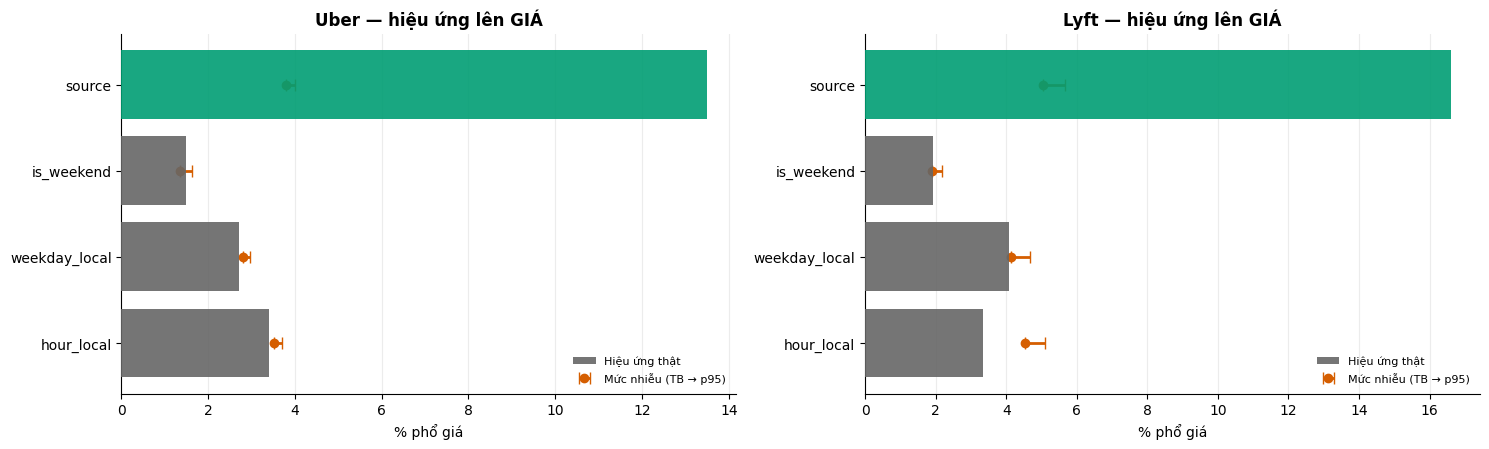

Cot xanh vuot qua diem do = hieu ung THAT. Nam trong = chi la nhieu.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for a, (r, ten) in zip(ax, [(r_u, "Uber"), (r_l, "Lyft")]):
    y = np.arange(len(r))
    a.barh(y, r["Thật %"], color=[GREEN if "THẬT" in k else MUT for k in r["Kết luận"]],
           alpha=.9, zorder=3, label="Hiệu ứng thật")
    a.errorbar(r["Nhiễu TB %"], y, xerr=[r["Nhiễu TB %"] - r["Nhiễu TB %"],
               r["Nhiễu p95 %"] - r["Nhiễu TB %"]], fmt="o", color=RED, ms=6,
               capsize=4, lw=2, label="Mức nhiễu (TB → p95)")
    a.set_yticks(y); a.set_yticklabels(r["Yếu tố"], fontsize=10)
    a.set_xlabel("% phổ giá"); a.set_title(f"{ten} — hiệu ứng lên GIÁ", fontweight="bold")
    a.legend(fontsize=8, frameon=False); a.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()
print("Cot xanh vuot qua diem do = hieu ung THAT. Nam trong = chi la nhieu.")

**3b. Đối chứng độc lập — mức tăng R² khi thêm giờ**

Phép thử hoán vị phụ thuộc cách chia bin. Kiểm tra lại bằng cách hoàn toàn khác.

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def tang_r2(dd, them, nen=("name", "distance")):
    d = dd.sample(min(150000, len(dd)), random_state=0)
    def _r2(cols):
        X = d[list(cols)].copy(); cats = []
        for c in cols:
            if not pd.api.types.is_numeric_dtype(X[c]):
                X[c] = X[c].astype("category"); cats.append(c)
        a, b_, c_, e = train_test_split(X, d.price, test_size=.25, random_state=42)
        m = HistGradientBoostingRegressor(max_iter=200, learning_rate=.06,
                categorical_features=cats if cats else None, random_state=42).fit(a, c_)
        return r2_score(e, m.predict(b_))
    return _r2(nen), _r2(tuple(nen) + (them,))

for ten, dd in [("Uber", dfU), ("Lyft", dfL)]:
    print(f"{ten}:")
    for c in ["hour_local", "weekday_local", "source"]:
        a, b_ = tang_r2(dd, c)
        print(f"   nen(name+distance)={a:.4f}  + {c:<16} -> {b_:.4f}   ({b_-a:+.4f})")
    print()
print("=> Giong ket qua hoan vi: gio/thu khong dong gop, source co dong gop nho.")

Uber:
   nen(name+distance)=0.9493  + hour_local       -> 0.9491   (-0.0003)
   nen(name+distance)=0.9493  + weekday_local    -> 0.9490   (-0.0003)
   nen(name+distance)=0.9493  + source           -> 0.9518   (+0.0024)

Lyft:
   nen(name+distance)=0.9036  + hour_local       -> 0.9035   (-0.0001)
   nen(name+distance)=0.9036  + weekday_local    -> 0.9034   (-0.0002)
   nen(name+distance)=0.9036  + source           -> 0.9101   (+0.0065)

=> Giong ket qua hoan vi: gio/thu khong dong gop, source co dong gop nho.


**4. 🔥 Giờ ảnh hưởng tới HỆ SỐ NHÂN không?**

Dùng bảng **cấp thị trường** (đã bỏ Shared, khử trùng lặp).

In [8]:
def hieu_ung_surge(cot, n_hoan_vi=12):
    """Bien do ty le surge giua cac nhom, so voi nhieu hoan vi."""
    def _do(key):
        g = TT.groupby(key, observed=True).co_surge.mean()
        return g.std() * 100          # do lech ty le surge giua cac nhom (diem %)
    k = binned(TT[cot]).rename("_k")
    that = _do(k)
    nhieu = np.array([_do(pd.Series(rng.permutation(k.values), index=k.index, name="_k"))
                      for _ in range(n_hoan_vi)])
    return that, nhieu.mean(), np.percentile(nhieu, 95), that > np.percentile(nhieu, 95)

rows = []
for c in ["hour_local", "weekday_local", "is_weekend", "source", "destination"]:
    t, n, p, ok = hieu_ung_surge(c)
    rows.append({"Yếu tố": c, "Độ lệch thật (điểm %)": round(t, 3),
                 "Nhiễu TB": round(n, 3), "Nhiễu p95": round(p, 3),
                 "Kết luận": "✅ THẬT" if ok else "❌ chỉ là nhiễu"})
rs = pd.DataFrame(rows)
display(rs)
print("Doc: do lech ty le surge giua cac nhom, tinh bang DIEM PHAN TRAM.")

,Yếu tố,Độ lệch thật (điểm %),Nhiễu TB,Nhiễu p95,Kết luận
0,hour_local,0.315,0.252,0.353,❌ chỉ là nhiễu
1,weekday_local,0.237,0.209,0.294,❌ chỉ là nhiễu
2,is_weekend,0.232,0.115,0.217,✅ THẬT
3,source,4.456,0.299,0.422,✅ THẬT
4,destination,0.569,0.269,0.337,✅ THẬT


Doc: do lech ty le surge giua cac nhom, tinh bang DIEM PHAN TRAM.


GIO CAO DIEM (top 25% ty le surge): [3, 7, 8, 13, 15, 19]
  Ty le surge: 7.76% -> 9.84%   (1.27 lan)
  Cuong do   : 1.418 -> 1.464   (1.03 lan)

=> Gio anh huong TAN SUAT nhung khong anh huong CUONG DO.


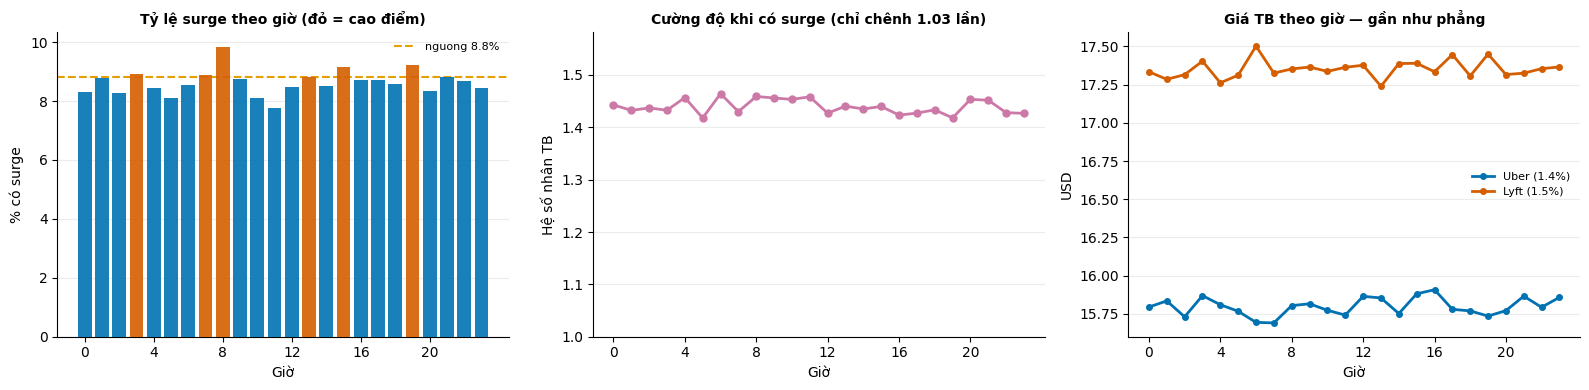

In [9]:
h_s = TT.groupby("hour_local").agg(n=("co_surge", "size"), surge=("co_surge", "mean"),
                                    muc=("surge", lambda s: s[s > 1].mean()))
thr = h_s.surge.quantile(.75)
PEAK = sorted(h_s[h_s.surge >= thr].index.tolist())
print(f"GIO CAO DIEM (top 25% ty le surge): {PEAK}")
print(f"  Ty le surge: {h_s.surge.min()*100:.2f}% -> {h_s.surge.max()*100:.2f}%"
      f"   ({h_s.surge.max()/h_s.surge.min():.2f} lan)")
print(f"  Cuong do   : {h_s.muc.min():.3f} -> {h_s.muc.max():.3f}"
      f"   ({h_s.muc.max()/h_s.muc.min():.2f} lan)")
print()
print("=> Gio anh huong TAN SUAT nhung khong anh huong CUONG DO.")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(h_s.index, h_s.surge * 100,
          color=[RED if x in PEAK else BLUE for x in h_s.index], alpha=.9, zorder=3)
ax[0].axhline(thr * 100, color=ORANGE, ls="--", lw=1.5, label=f"nguong {thr*100:.1f}%")
ax[0].set_title("Tỷ lệ surge theo giờ (đỏ = cao điểm)", fontweight="bold", fontsize=10)
ax[0].set_ylabel("% có surge"); ax[0].legend(fontsize=8, frameon=False)

ax[1].plot(h_s.index, h_s.muc, "o-", color=PURPLE, lw=2, ms=5)
ax[1].set_ylim(1.0, h_s.muc.max() * 1.08)
ax[1].set_title(f"Cường độ khi có surge (chỉ chênh {h_s.muc.max()/h_s.muc.min():.2f} lần)",
                fontweight="bold", fontsize=10)
ax[1].set_ylabel("Hệ số nhân TB")

for hh, dd in [("Uber", dfU), ("Lyft", dfL)]:
    gm = dd.groupby("hour_local").price.mean()
    ax[2].plot(gm.index, gm.values, "o-", color=MAU_HANG[hh], lw=2, ms=4,
               label=f"{hh} ({(gm.max()/gm.min()-1)*100:.1f}%)")
ax[2].set_title("Giá TB theo giờ — gần như phẳng", fontweight="bold", fontsize=10)
ax[2].set_ylabel("USD"); ax[2].legend(fontsize=8, frameon=False)
for a in ax: a.set_xlabel("Giờ"); a.set_xticks(range(0, 24, 4)); a.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**5. 📅 Thứ trong tuần & bản đồ nhiệt**

,thu,n,surge,gia_TB
weekday_local,,,,
0,T2,23772,8.68,17.329
1,T3,15853,8.90,17.310
2,T4,16428,8.97,17.337
3,T5,15668,8.44,17.419
4,T6,15933,8.64,17.352
5,T7,15819,8.43,17.386
6,CN,16594,8.36,17.349


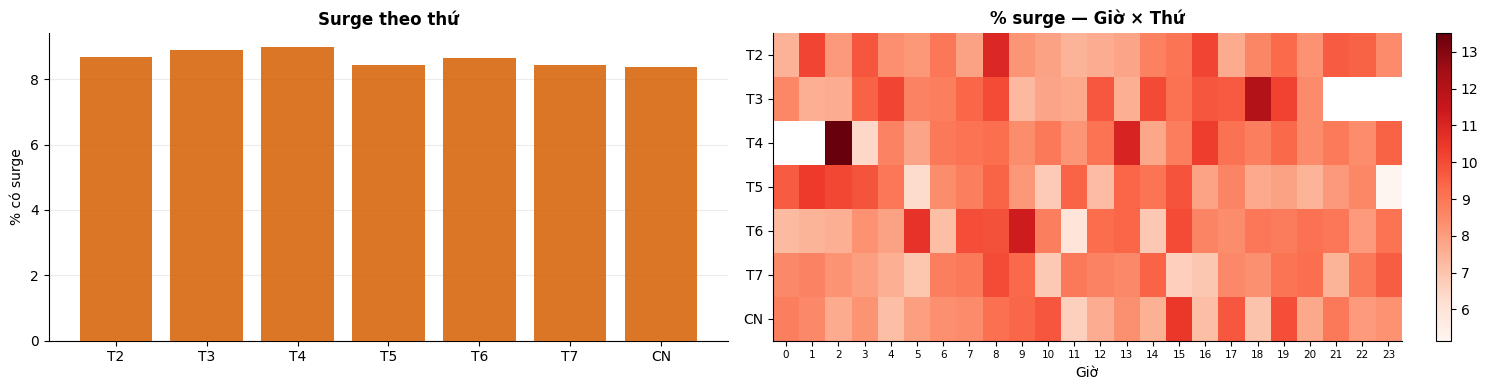

In [10]:
w = TT.groupby("weekday_local").agg(n=("co_surge", "size"), surge=("co_surge", "mean"))
w["thu"] = [DAYS[i] for i in w.index]
wp = dfL.groupby("weekday_local").price.mean()
w["gia_TB"] = wp.values
display(w[["thu", "n", "surge", "gia_TB"]].assign(
    surge=lambda x: (x.surge * 100).round(2)).round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(w.thu, w.surge * 100, color=RED, alpha=.85, zorder=3)
ax[0].set_ylabel("% có surge"); ax[0].set_title("Surge theo thứ", fontweight="bold")
pv = TT.pivot_table(index="weekday_local", columns="hour_local",
                    values="co_surge", aggfunc="mean") * 100
im = ax[1].imshow(pv, cmap="Reds", aspect="auto")
ax[1].set_xticks(range(24)); ax[1].set_xticklabels(range(24), fontsize=7.5)
ax[1].set_yticks(range(len(pv))); ax[1].set_yticklabels([DAYS[i] for i in pv.index])
ax[1].set_xlabel("Giờ"); ax[1].set_title("% surge — Giờ × Thứ", fontweight="bold")
ax[1].grid(False); fig.colorbar(im, ax=ax[1], fraction=0.025)
ax[0].grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**6. ⚠️ Bẫy mã hoá: vì sao Pearson của giờ ≈ 0**

Quan hệ giờ ↔ surge **không đơn điệu** (cao 8h → thấp 11h → cao 17h) nên tương quan
tuyến tính mù hoàn toàn.

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

print(f"Pearson r(gio, surge) = {np.corrcoef(TT.hour_local, TT.surge)[0,1]:.4f}"
      f"   <- gan 0, tuong nhu vo dung\n")
d = TT.sample(min(80000, len(TT)), random_state=0)
base = pd.DataFrame(index=d.index)
base["nen"] = 1.0
bien_the = {
    "khong co gio": base,
    "gio dang SO (0-23)": base.assign(h=d.hour_local),
    "gio dang CHU KY": base.assign(sin=np.sin(2*np.pi*d.hour_local/24),
                                    cos=np.cos(2*np.pi*d.hour_local/24)),
    "gio dang PHAN LOAI": base.assign(**{f"h{i}": (d.hour_local == i).astype(int)
                                          for i in range(24)}),
}
print("Kha nang du doan surge (ROC-AUC):")
for k, X in bien_the.items():
    s = cross_val_score(HistGradientBoostingClassifier(max_iter=120, random_state=42),
                        X, d.co_surge, cv=3, scoring="roc_auc").mean()
    print(f"   {k:<24}: {s:.4f}")
print()
print("=> Gio CO tin hieu nho, nhung Pearson khong bat duoc.")
print("   Bai hoc: khong danh gia bien tuan hoan bang tuong quan tuyen tinh.")

Pearson r(gio, surge) = -0.0004   <- gan 0, tuong nhu vo dung

Kha nang du doan surge (ROC-AUC):
   khong co gio            : 0.5000
   gio dang SO (0-23)      : 0.5096
   gio dang CHU KY         : 0.5096
   gio dang PHAN LOAI      : 0.5096

=> Gio CO tin hieu nho, nhung Pearson khong bat duoc.
   Bai hoc: khong danh gia bien tuan hoan bang tuong quan tuyen tinh.


**7. 📌 Kết luận**

In [12]:
print("="*70); print("THOI GIAN — KET LUAN"); print("="*70)
print()
print("1) VOI GIA: KHONG anh huong")
for ten, r in [("Uber", r_u), ("Lyft", r_l)]:
    x = r[r["Yếu tố"] == "hour_local"].iloc[0]
    print(f"   {ten}: that {x['Thật %']}% vs nhieu p95 {x['Nhiễu p95 %']}%  -> {x['Kết luận']}")
print("   Doi chung R2: them gio vao (name+distance) khong cai thien")
print()
print("2) VOI HE SO NHAN: co anh huong nhung YEU")
xs = rs[rs["Yếu tố"] == "hour_local"].iloc[0]
print(f"   Do lech that {xs['Độ lệch thật (điểm %)']} diem % vs nhieu p95 "
      f"{xs['Nhiễu p95']}  -> {xs['Kết luận']}")
print(f"   Gio cao diem: {PEAK}")
print(f"   Ty le surge chenh {h_s.surge.max()/h_s.surge.min():.2f} lan; "
      f"cuong do chenh chi {h_s.muc.max()/h_s.muc.min():.2f} lan")
print(f"   So sanh: KHU VUC lech {rs[rs['Yếu tố']=='source'].iloc[0]['Độ lệch thật (điểm %)']} "
      f"diem % -> manh hon nhieu")
print()
print("3) SO BAN GHI KHONG PHAI NHU CAU")
print(f"   Bien thien chi {h.max()/h.min():.2f} lan (nhu cau that phai 8-15 lan)")
print(f"   12 khu hinh dang giong nhau r={cor.mean():.2f}; khong lien quan surge")
print("   -> KHONG dung lam feature; KHONG ket luan ve 'gio cao diem nhu cau'")
print()
print("4) KHUYEN NGHI")
print("   - BO gio khoi model GIA")
print("   - GIU gio cho model SURGE, ma hoa PHAN LOAI hoac CHU KY")
print("   - Uu tien source hon hour khi chon feature cho surge")

THOI GIAN — KET LUAN

1) VOI GIA: KHONG anh huong
   Uber: that 3.39% vs nhieu p95 3.71%  -> ❌ chỉ là nhiễu
   Lyft: that 3.35% vs nhieu p95 5.11%  -> ❌ chỉ là nhiễu
   Doi chung R2: them gio vao (name+distance) khong cai thien

2) VOI HE SO NHAN: co anh huong nhung YEU
   Do lech that 0.315 diem % vs nhieu p95 0.353  -> ❌ chỉ là nhiễu
   Gio cao diem: [3, 7, 8, 13, 15, 19]
   Ty le surge chenh 1.27 lan; cuong do chenh chi 1.03 lan
   So sanh: KHU VUC lech 4.456 diem % -> manh hon nhieu

3) SO BAN GHI KHONG PHAI NHU CAU
   Bien thien chi 1.34 lan (nhu cau that phai 8-15 lan)
   12 khu hinh dang giong nhau r=0.80; khong lien quan surge
   -> KHONG dung lam feature; KHONG ket luan ve 'gio cao diem nhu cau'

4) KHUYEN NGHI
   - BO gio khoi model GIA
   - GIU gio cho model SURGE, ma hoa PHAN LOAI hoac CHU KY
   - Uu tien source hon hour khi chon feature cho surge
